# Notebook 3: Generate Synthetic T1 Volumes & Compute Matched-Slice FID
## Corrected version for your current AE + diffusion checkpoints

This notebook loads the trained AutoencoderKL and latent diffusion UNet, verifies that the checkpoint architecture matches the inference configuration, generates synthetic T1 volumes, optionally shows display-only live previews during generation, and computes a fair matched-slice FID against the held-out test split.

**Current checkpoint assumptions:** `AE_LATENT_CHANNELS=8`, `DIFFUSION_IN_CHANNELS=8`, `DIFFUSION_OUT_CHANNELS=8`, and `TARGET_SHAPE=(128, 128, 96)`.

**Local setup:** the dataset is read from the workspace folder `T1`, and outputs are written under the local folder `generated3`.

**Important correction:** the AE/diffusion notebooks used `Resized(..., mode=("nearest",))`, so this generation/evaluation notebook also uses nearest resizing for real-volume preprocessing. This avoids a preprocessing mismatch during AE sanity checking and FID comparison.

**Metric correction:** AE sanity-check metrics are computed after clamping `[-1, 1]` and converting both real and reconstructed tensors to `[0, 1]` with `data_range=1.0`.


## Configuration update note

This corrected notebook is matched to the current AE and diffusion notebooks you shared:

- `SPATIAL_SIZE / TARGET_SHAPE = (128, 128, 96)`
- `AE_LATENT_CHANNELS = 8`
- `DIFFUSION_IN_CHANNELS = 8`
- `DIFFUSION_OUT_CHANNELS = 8`
- `AE_NUM_CHANNELS = (32, 64, 128)`
- `DIFFUSION_NUM_CHANNELS = (64, 128, 128)`
- `DIFFUSION_NUM_HEAD_CHANNELS = (0, 64, 64)`
- `DDPM_NUM_TIMESTEPS = 1000`
- `DDPM_BETA_START = 0.0015`
- `DDPM_BETA_END = 0.0195`
- Real preprocessing resize mode: `nearest`, to match the already-trained AE/diffusion notebooks.

The notebook uses strict checkpoint loading so architecture mismatches fail early instead of silently producing invalid blurry/blob-like generations.

The FID section uses TorchMetrics `FrechetInceptionDistance` and matched slices: both real and synthetic volumes are evaluated in the same preprocessed target shape, using the same axis, same slice percentages, and same exact slice indices.


In [1]:
%pip install monai monai-generative nibabel scikit-image tqdm matplotlib torch-fidelity lpips pandas scipy torchvision

import os
import re
import random
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
from scipy.linalg import sqrtm
from scipy.stats import entropy

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.amp.autocast_mode import autocast

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.filters import sobel

from torchvision.models import inception_v3, Inception_V3_Weights

from monai.data.dataset import Dataset
from monai.utils.misc import set_determinism
from monai.transforms.utility.dictionary import EnsureChannelFirstd, EnsureTyped
from monai.transforms.spatial.dictionary import Resized, Orientationd, Spacingd
from monai.transforms.compose import Compose
from monai.transforms.io.dictionary import LoadImaged
from monai.transforms.intensity.dictionary import ScaleIntensityRangePercentilesd

from generative.networks.nets import AutoencoderKL, DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler

LOCAL_DATASET_ROOT = Path("T1")
if not LOCAL_DATASET_ROOT.exists():
    raise FileNotFoundError(f"Local dataset folder not found: {LOCAL_DATASET_ROOT.resolve()}")

print(f"✓ Using local dataset folder: {LOCAL_DATASET_ROOT.resolve()}")
print("✓ Skipping dataset download because the data already exists locally.")
print("✓ All packages imported successfully")


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\samle\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\samle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Using local dataset folder: C:\MDS03\MDS03_Backend\T1
✓ Skipping dataset download because the data already exists locally.
✓ All packages imported successfully


C:\Users\samle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\generative\networks\layers\vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
C:\Users\samle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\generative\networks\layers\vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Number of GPUs:", torch.cuda.device_count())
else:
    print("No GPU detected. Runtime may be using CPU.")

CUDA available: True
GPU name: NVIDIA GeForce RTX 3060
Number of GPUs: 1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Download dataset from Google Drive
import subprocess
subprocess.run(["pip", "install", "-q", "gdown"], check=True)
subprocess.run(["gdown", "--fuzzy", "https://drive.google.com/file/d/1Ox7sCEqtM7gOM8Y72H1bqHULtWolfTu3/view?usp=sharing"], check=True)

# Unzip the downloaded dataset
import zipfile
import os

dataset_zip_path = "/content/final-clean-data.zip"
dataset_extract_path = "/content/dataset"

os.makedirs(dataset_extract_path, exist_ok=True)

if os.path.exists(dataset_zip_path):
    print(f"Unzipping {dataset_zip_path} to {dataset_extract_path}...")
    with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_extract_path)
    print("✓ Dataset unzipped successfully")
else:
    print(f"Warning: {dataset_zip_path} not found. Skipping unzip.")

print("✓ Google Drive mounted and dataset downloaded")

Mounted at /content/drive
Unzipping /content/final-clean-data.zip to /content/dataset...
✓ Dataset unzipped successfully
✓ Google Drive mounted and dataset downloaded


In [3]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
if torch.cuda.is_available():
    torch.cuda.ipc_collect()

print("✓ Memory cleared")

✓ Memory cleared


## 1. Configuration & Load Checkpoints

In [7]:
# Configuration matched to the CURRENT trained AE + diffusion model
# Values taken from your latest training documentation screenshot.

DATASET_ROOT = Path("T1")
OUTPUT_ROOT = Path("generated3")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
set_determinism(seed=SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print(f"Device: {device}, AMP: {use_amp}")

# Generation / FID controls
FID_NUM_SYNTH = 1
FID_BATCH_SIZE_GEN = 1  # Safer for 3D generation; increase only if GPU memory is enough
FID_SLICE_AXIS = 2
FID_IMAGE_SIZE = 299
NORM_LOW_PCT = 0.5
NORM_HIGH_PCT = 99.5

# ============================================================
# TRAINING CONFIGURATION - MATCHED TO YOUR LATEST DOCUMENTATION
# ============================================================

# Data / volume configuration
SPATIAL_SIZE = (128, 128, 96)
TARGET_SHAPE = SPATIAL_SIZE
PIXDIM = (1.0, 1.0, 1.0)
TARGET_PIXDIM = PIXDIM

# Autoencoder configuration
AE_LATENT_CHANNELS = 8 # Changed from 4 to 8 to match checkpoint
AE_NUM_CHANNELS = (32, 64, 128)
AE_NUM_RES_BLOCKS = 2
AE_NORM_NUM_GROUPS = 16
AE_ATTENTION_LEVELS = (False, False, True)
KL_WEIGHT = 5e-7
AE_EPOCHS = 120
AE_LR = 5e-5

# Diffusion UNet configuration
DIFFUSION_IN_CHANNELS = 8 # Changed from 4 to 8 to match AE_LATENT_CHANNELS
DIFFUSION_OUT_CHANNELS = 8 # Changed from 4 to 8 to match AE_LATENT_CHANNELS
DIFFUSION_NUM_CHANNELS = (64, 128, 128)
DIFFUSION_NUM_RES_BLOCKS = 2
DIFFUSION_ATTENTION_LEVELS = (False, True, True)
DIFFUSION_NUM_HEAD_CHANNELS = (0, 64, 64)
DIFF_EPOCHS = 260
DIFF_LR = 3e-5
USE_EMA = True
EMA_DECAY = 0.9995
OFFSET_NOISE = 0.1
GRAD_CLIP = 1.0

# Scheduler configuration
DDPM_NUM_TIMESTEPS = 1000
DDPM_BETA_START = 0.0015
DDPM_BETA_END = 0.0195
# IMPORTANT: this must match training. Your earlier notes mention scaled_linear_beta.
# If the checkpoint was trained with linear_beta, change this to "linear_beta".
DDPM_BETA_SCHEDULE = "scaled_linear_beta"

# Training/runtime metadata
BATCH_SIZE = 1
NUM_WORKERS = 2

# Data split
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
T1_FILENAME_FILTER = "t1"

# Output paths
ae_ckpt_dir = Path(".")
diff_ckpt_dir = Path(".")
ae_best_path = ae_ckpt_dir / "autoencoder_best.pth"
diff_best_path = diff_ckpt_dir / "latent_diffusion_best.pth"

generated_dir = OUTPUT_ROOT / "generated"
generated_dir.mkdir(parents=True, exist_ok=True)

print("Configuration loaded ✓")
print(f"Target shape: {TARGET_SHAPE}")
print(f"AE latent channels: {AE_LATENT_CHANNELS}")
print(f"AE channels: {AE_NUM_CHANNELS}")
print(f"Diffusion channels: in={DIFFUSION_IN_CHANNELS}, out={DIFFUSION_OUT_CHANNELS}, blocks={DIFFUSION_NUM_CHANNELS}")
print(f"DDPM: timesteps={DDPM_NUM_TIMESTEPS}, beta_start={DDPM_BETA_START}, beta_end={DDPM_BETA_END}, schedule={DDPM_BETA_SCHEDULE}")


Device: cuda, AMP: True
Configuration loaded ✓
Target shape: (128, 128, 96)
AE latent channels: 8
AE channels: (32, 64, 128)
Diffusion channels: in=8, out=8, blocks=(64, 128, 128)
DDPM: timesteps=1000, beta_start=0.0015, beta_end=0.0195, schedule=scaled_linear_beta


## 2. Load Trained Models and Prepare Data

In [8]:
# ============================================================
# Load trained AutoencoderKL and Latent Diffusion UNet
# Architecture MUST match the training configuration.
# ============================================================

# Load autoencoder
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    num_channels=AE_NUM_CHANNELS,
    latent_channels=AE_LATENT_CHANNELS,
    num_res_blocks=AE_NUM_RES_BLOCKS,
    norm_num_groups=AE_NORM_NUM_GROUPS,
    attention_levels=AE_ATTENTION_LEVELS,
).to(device)

if not ae_best_path.exists():
    raise FileNotFoundError(f"Autoencoder checkpoint not found: {ae_best_path}")

ae_ckpt = torch.load(ae_best_path, map_location=device)

try:
    autoencoder.load_state_dict(ae_ckpt["autoencoder_state_dict"], strict=True)
    print("✓ Autoencoder checkpoint loaded with strict=True")
except RuntimeError as e:
    print("❌ Autoencoder architecture does not match the checkpoint.")
    print("Check AE_LATENT_CHANNELS, AE_NUM_CHANNELS, attention_levels, and num_res_blocks.")
    raise e

autoencoder.eval()
for p in autoencoder.parameters():
    p.requires_grad = False
print(f"✓ Loaded autoencoder from {ae_best_path}")

# Load diffusion model
unet_model = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=DIFFUSION_IN_CHANNELS,
    out_channels=DIFFUSION_OUT_CHANNELS,
    num_channels=DIFFUSION_NUM_CHANNELS,
    attention_levels=DIFFUSION_ATTENTION_LEVELS,
    num_head_channels=DIFFUSION_NUM_HEAD_CHANNELS,
    num_res_blocks=DIFFUSION_NUM_RES_BLOCKS,
).to(device)

scheduler = DDPMScheduler(
    num_train_timesteps=DDPM_NUM_TIMESTEPS,
    beta_start=DDPM_BETA_START,
    beta_end=DDPM_BETA_END,
    schedule=DDPM_BETA_SCHEDULE,
)

if not diff_best_path.exists():
    raise FileNotFoundError(f"Diffusion checkpoint not found: {diff_best_path}")

diff_ckpt = torch.load(diff_best_path, map_location=device)

# Use EMA weights when present because they usually sample more smoothly.
# Prefer EMA weights if the checkpoint contains them;# Prefer EMA weights if the checkpoint contains them; otherwise use normal UNet weights.
# EMA usually gives smoother and more stable sampling, but only if it was saved during training.
diffusion_state_key = None
for candidate_key in [
    "ema_unet_state_dict",
    "unet_ema_state_dict",
    "ema_state_dict",
    "unet_state_dict",
    "model_state_dict",
    "state_dict",
]:
    if candidate_key in diff_ckpt:
        diffusion_state_key = candidate_key
        break

if diffusion_state_key is None:
    raise KeyError(
        f"Could not find a diffusion model state dict in checkpoint. Available keys: {list(diff_ckpt.keys())}"
    )

try:
    unet_model.load_state_dict(diff_ckpt[diffusion_state_key], strict=True)
    print(f"✓ Diffusion UNet checkpoint loaded with strict=True from key: {diffusion_state_key}")
except RuntimeError as e:
    print("❌ Diffusion UNet architecture does not match the checkpoint.")
    print("Check DIFFUSION_IN_CHANNELS, DIFFUSION_OUT_CHANNELS, DIFFUSION_NUM_CHANNELS,")
    print("DIFFUSION_ATTENTION_LEVELS, DIFFUSION_NUM_HEAD_CHANNELS, and num_res_blocks.")
    print("Checkpoint state key used:", diffusion_state_key)
    raise e

scale_factor_runtime = float(diff_ckpt.get("scale_factor", 1.0))
unet_model.eval()
print(f"✓ Loaded diffusion model from {diff_best_path}")
print(f"  Scale factor from checkpoint or fallback: {scale_factor_runtime:.6f}")

if abs(scale_factor_runtime - 1.0) < 1e-8 and "scale_factor" not in diff_ckpt:
    print("⚠️  No scale_factor found in diffusion checkpoint. Using fallback scale_factor=1.0.")
    print("   If your training used latent scaling, this can badly affect generation quality.")

# Data discovery - same split as training documentation: 80/10/10
def natural_key(text: str):
    """
    Function description:
        Split text into numeric and non-numeric parts for natural sorting.
    
    Parameters:
        text (str): Text value to split.
    
    Returns:
        list[int | str]: Sort key that keeps numbered filenames in human order.
    """
    return [int(c) if c.isdigit() else c for c in re.split(r"(\d+)", text)]

def discover_nifti_files(dataset_root: Path, filename_filter: str | None = "t1") -> list[Path]:
    """
    Function description:
        Discover NIfTI files under a dataset root with an optional filename filter.
    
    Parameters:
        dataset_root (Path): Root folder to search recursively.
        filename_filter (str | None): Optional substring required in each filename.
    
    Returns:
        list[Path]: Sorted NIfTI file paths.
    """
    nii_files = sorted(dataset_root.rglob("*.nii*"), key=lambda p: natural_key(str(p).lower()))
    if filename_filter:
        k = filename_filter.lower()
        nii_files = [p for p in nii_files if k in p.name.lower()]
    if not nii_files:
        raise ValueError(f"No NIfTI files found under {dataset_root} with filter={filename_filter!r}")
    return nii_files

def build_data_dicts(paths: list[Path]) -> list[dict]:
    """
    Function description:
        Convert NIfTI paths into MONAI-style data dictionaries.
    
    Parameters:
        paths (list[Path]): NIfTI file paths to convert.
    
    Returns:
        list[dict]: Records containing image paths and case identifiers.
    """
    return [{"image": str(p), "case_id": p.stem} for p in paths]

t1_root = DATASET_ROOT / "T1" if (DATASET_ROOT / "T1").exists() else DATASET_ROOT
all_t1_nii = discover_nifti_files(t1_root, filename_filter=T1_FILENAME_FILTER)
all_files = build_data_dicts(all_t1_nii)

# Recreate the same deterministic split used for evaluation against real T1 volumes.
rng = random.Random(SEED)
rng.shuffle(all_files)

n_total = len(all_files)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)
train_files = all_files[:n_train]
val_files = all_files[n_train:n_train + n_val]
test_files = all_files[n_train + n_val:]

print(f"Total T1 files: {n_total}")
print(f"Train/Val/Test split: {len(train_files)}/{len(val_files)}/{len(test_files)}")
print(f"Test set size: {len(test_files)}")

✓ Autoencoder checkpoint loaded with strict=True
✓ Loaded autoencoder from autoencoder_best.pth
✓ Diffusion UNet checkpoint loaded with strict=True from key: ema_unet_state_dict
✓ Loaded diffusion model from latent_diffusion_best.pth
  Scale factor from checkpoint or fallback: 1.000846
Total T1 files: 494
Train/Val/Test split: 395/49/50
Test set size: 50


## 2.5 Pre-run Fact Check and Sanity Checks

Run this section **before generating 1,000 volumes**. It checks whether the dataset, checkpoints, preprocessing, latent shape, scale factor, autoencoder reconstruction, and scheduler setup are internally consistent.

The most important diagnostic is the autoencoder reconstruction preview. If AE reconstruction is already blurry, the generation blur is likely caused by the autoencoder bottleneck/checkpoint. If AE reconstruction is sharp but generated samples are blurry, the issue is more likely the diffusion model, scheduler, scale factor, or diffusion checkpoint.


PRE-RUN FACT CHECK

[1] Path checks
DATASET_ROOT: T1 | exists=True
OUTPUT_ROOT: generated3 | exists=True
AE checkpoint: autoencoder_best.pth | exists=True
Diffusion checkpoint: latent_diffusion_best.pth | exists=True
Generated output directory: generated3\generated | exists=True

[2] Dataset and split checks
Total T1 files discovered: 494
Test files: 50
First test file: T1\BraTS20_Training_173_t1.nii
Raw first test shape: (240, 240, 155)
Raw first test range: min=0.0000, max=7779.0000, mean=551.1906, std=1312.7567

[3] Checkpoint content checks
AE checkpoint keys: ['epoch', 'autoencoder_state_dict', 'optimizer_state_dict', 'scaler_state_dict', 'lr_scheduler_state_dict', 'best_val_loss', 'ae_patience_counter', 'config', 'history']
✓ AE checkpoint contains autoencoder_state_dict
Diffusion checkpoint keys: ['epoch', 'unet_state_dict', 'ema_unet_state_dict', 'optimizer_state_dict', 'scaler_state_dict', 'lr_scheduler_state_dict', 'best_val_loss', 'diff_patience_counter', 'scale_factor']
✓ D

C:\Users\samle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


AE input shape: (1, 1, 128, 128, 96)
AE latent shape: (1, 8, 32, 32, 24)
AE recon shape: (1, 1, 128, 128, 96)
AE input range: min=-1.0000, max=1.0000, std=0.5855
AE recon range: min=-1.0313, max=1.0349, std=0.5841
AE reconstruction metrics computed after clamp + correct data range:
  [0,1] MAE:   0.007960
  [0,1] MSE:   0.000814
  [0,1] PSNR:  30.8929
  [0,1] SSIM:  0.9704
  [-1,1] MSE:  0.003257
  [-1,1] PSNR with data_range=2.0: 30.8929


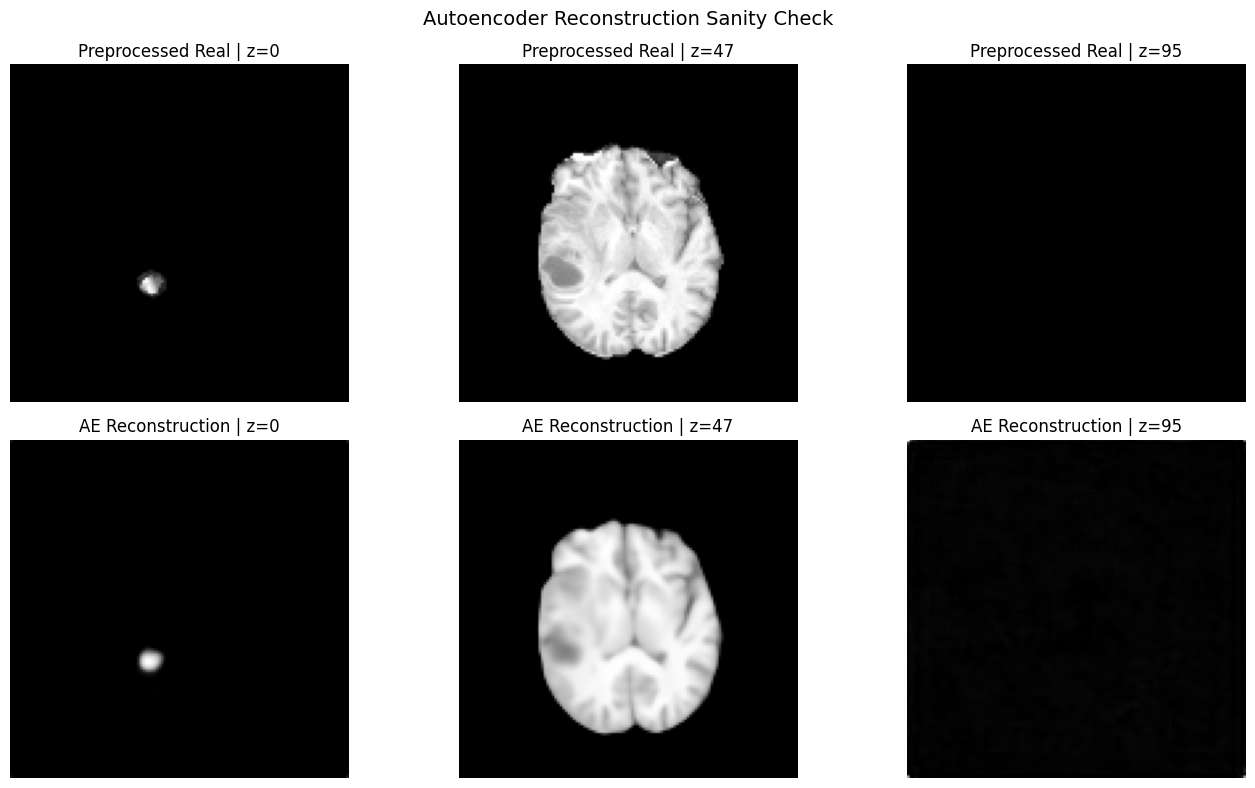

Saved AE reconstruction preview: generated3\factcheck\ae_reconstruction_sanity_check.png

[7] Random latent decode smoke check
Random latent decoded shape: (1, 1, 128, 128, 96)
Random latent decoded range: min=-1.3090, max=2.3546, mean=-0.7043, std=0.3632

[8] Fact-check summary
--------------------------------------------------------------------------------
Status: PASS
Warnings: 0
Errors: 0
Saved summary JSON: generated3\factcheck\pre_run_factcheck_summary.json
--------------------------------------------------------------------------------

All core checks passed. You can proceed to the generation cell.


In [9]:

# ============================================================
# 2.5 Pre-run Fact Check and Sanity Checks
# ============================================================

import json
import warnings
from pathlib import Path

import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


print("=" * 80)
print("PRE-RUN FACT CHECK")
print("=" * 80)

factcheck_dir = OUTPUT_ROOT / "factcheck"
factcheck_dir.mkdir(parents=True, exist_ok=True)

factcheck = {
    "status": "PASS",
    "warnings": [],
    "errors": [],
    "config": {},
}


# Fact-check helpers collect warnings/errors before any expensive generation starts.
def record_warning(msg):
    """
    Function description:
        Record a warning message in the pre-run fact-check report.
    
    Parameters:
        msg (object): Warning message to store and print.
    
    Returns:
        None
    """
    factcheck["warnings"].append(str(msg))
    print(f"⚠️  WARNING: {msg}")


def record_error(msg):
    """
    Function description:
        Record an error message and mark the fact-check status as failed.
    
    Parameters:
        msg (object): Error message to store and print.
    
    Returns:
        None
    """
    factcheck["errors"].append(str(msg))
    factcheck["status"] = "FAIL"
    print(f"❌ ERROR: {msg}")


def record_ok(msg):
    """
    Function description:
        Print a successful fact-check message.
    
    Parameters:
        msg (object): Success message to print.
    
    Returns:
        None
    """
    print(f"✓ {msg}")


# ------------------------------------------------------------
# 1. Path checks
# ------------------------------------------------------------

print("\n[1] Path checks")

paths_to_check = {
    "DATASET_ROOT": DATASET_ROOT,
    "OUTPUT_ROOT": OUTPUT_ROOT,
    "AE checkpoint": ae_best_path,
    "Diffusion checkpoint": diff_best_path,
    "Generated output directory": generated_dir,
}

for name, path in paths_to_check.items():
    path = Path(path)
    exists = path.exists()
    print(f"{name}: {path} | exists={exists}")
    if name not in ["Generated output directory"] and not exists:
        record_error(f"Missing required path: {name} -> {path}")

# Generated dir can be created if missing
generated_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. Dataset and split checks
# ------------------------------------------------------------

print("\n[2] Dataset and split checks")

try:
    print(f"Total T1 files discovered: {len(all_files)}")
    print(f"Test files: {len(test_files)}")

    if len(all_files) == 0:
        record_error("No T1 files discovered.")
    if len(test_files) == 0:
        record_error("test_files is empty, so FID cannot compare against real volumes.")
    else:
        first_test_path = Path(test_files[0]["image"])
        print(f"First test file: {first_test_path}")
        if not first_test_path.exists():
            record_error(f"First test file does not exist: {first_test_path}")
        else:
            raw_img = nib.load(str(first_test_path))
            raw_data = raw_img.get_fdata()
            print(f"Raw first test shape: {raw_data.shape}")
            print(f"Raw first test range: min={raw_data.min():.4f}, max={raw_data.max():.4f}, mean={raw_data.mean():.4f}, std={raw_data.std():.4f}")
except Exception as e:
    record_error(f"Dataset check failed: {repr(e)}")


# ------------------------------------------------------------
# 3. Checkpoint content checks
# ------------------------------------------------------------

print("\n[3] Checkpoint content checks")

try:
    print(f"AE checkpoint keys: {list(ae_ckpt.keys())}")
    if "autoencoder_state_dict" not in ae_ckpt:
        record_error("AE checkpoint missing key: autoencoder_state_dict")
    else:
        record_ok("AE checkpoint contains autoencoder_state_dict")

    print(f"Diffusion checkpoint keys: {list(diff_ckpt.keys())}")
    if "unet_state_dict" not in diff_ckpt:
        record_error("Diffusion checkpoint missing key: unet_state_dict")
    else:
        record_ok("Diffusion checkpoint contains unet_state_dict")

    if "scale_factor" not in diff_ckpt:
        record_warning("Diffusion checkpoint does not contain scale_factor. Notebook is using fallback value.")
    else:
        record_ok(f"Diffusion checkpoint scale_factor found: {scale_factor_runtime:.6f}")

    if not np.isfinite(scale_factor_runtime) or scale_factor_runtime <= 0:
        record_error(f"Invalid scale_factor_runtime: {scale_factor_runtime}")
except Exception as e:
    record_error(f"Checkpoint content check failed: {repr(e)}")



# ------------------------------------------------------------
# 4. Model architecture and latent shape checks
# ------------------------------------------------------------

print("\n[4] Model architecture and latent shape checks")

try:
    print(f"TARGET_SHAPE: {TARGET_SHAPE}")
    print(f"TARGET_PIXDIM: {TARGET_PIXDIM}")
    print(f"AE_LATENT_CHANNELS: {AE_LATENT_CHANNELS}")
    print(f"DIFFUSION_IN_CHANNELS: {DIFFUSION_IN_CHANNELS}")
    print(f"DIFFUSION_OUT_CHANNELS: {DIFFUSION_OUT_CHANNELS}")
    if AE_LATENT_CHANNELS != DIFFUSION_IN_CHANNELS or AE_LATENT_CHANNELS != DIFFUSION_OUT_CHANNELS:
        record_error("AE latent channels must match diffusion in/out channels for latent diffusion generation.")
    else:
        record_ok("AE latent channels match diffusion in/out channels")
    print(f"AE_NUM_CHANNELS: {AE_NUM_CHANNELS}")
    print(f"DDPM timesteps: {scheduler.num_train_timesteps}")
    print(f"DDPM beta_start: {DDPM_BETA_START}")
    print(f"DDPM beta_end: {DDPM_BETA_END}")
    print(f"DDPM schedule: {DDPM_BETA_SCHEDULE}")

    autoencoder.eval()
    unet_model.eval()

    with torch.no_grad():
      # Verify model dimensions with a dummy volume before sampling real outputs.
      dummy = torch.zeros(1, 1, *TARGET_SHAPE, device=device)

      decoded_dummy, z_mu, z_sigma = autoencoder(dummy)

      inferred_latent_shape = tuple(z_mu.shape[2:])
      inferred_latent_channels = int(z_mu.shape[1])

      print(f"Inferred latent tensor shape: {tuple(z_mu.shape)}")
      print(f"Inferred latent spatial shape: {inferred_latent_shape}")
      print(f"Inferred latent channels: {inferred_latent_channels}")

      print(f"Decoded dummy shape: {tuple(decoded_dummy.shape)}")

    if inferred_latent_channels != AE_LATENT_CHANNELS:
        record_error(
            f"AE_LATENT_CHANNELS={AE_LATENT_CHANNELS} but autoencoder produced {inferred_latent_channels} channels."
        )
    else:
        record_ok("AE latent channel count matches AE_LATENT_CHANNELS")

    if tuple(decoded_dummy.shape[2:]) != tuple(TARGET_SHAPE):
        record_warning(
            f"Autoencoder decode output shape {tuple(decoded_dummy.shape[2:])} does not match TARGET_SHAPE {TARGET_SHAPE}. Generation/evaluation will resize if needed."
        )
    else:
        record_ok("Autoencoder decode output shape matches TARGET_SHAPE")

    # Save for later generation cell if not already defined
    LATENT_SPATIAL_SHAPE = inferred_latent_shape

except Exception as e:
    record_error(f"Latent shape check failed: {repr(e)}")


# ------------------------------------------------------------
# 5. Preprocessing check: real volume should become [1, H, W, D]
# ------------------------------------------------------------

print("\n[5] Preprocessing check")

try:
    factcheck_val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    EnsureTyped(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Resized(keys=["image"], spatial_size=TARGET_SHAPE, mode=("trilinear",)),
    ScaleIntensityRangePercentilesd(
        keys=["image"],
        lower=NORM_LOW_PCT,
        upper=NORM_HIGH_PCT,
        b_min=-1.0,
        b_max=1.0,
        clip=True,
    ),
    EnsureTyped(keys=["image"]),
])

    sample = factcheck_val_transforms(test_files[0])
    x = sample["image"]
    x = torch.as_tensor(x).float()

    print(f"Preprocessed real tensor shape: {tuple(x.shape)}")
    print(f"Preprocessed real range: min={x.min().item():.4f}, max={x.max().item():.4f}, mean={x.mean().item():.4f}, std={x.std().item():.4f}")

    if tuple(x.shape[1:]) != tuple(TARGET_SHAPE):
        record_error(f"Preprocessed real shape {tuple(x.shape[1:])} does not match TARGET_SHAPE {TARGET_SHAPE}")
    else:
        record_ok("Preprocessed real volume shape matches TARGET_SHAPE")

    if x.min().item() < -1.05 or x.max().item() > 1.05:
        record_warning("Preprocessed real volume is outside expected [-1, 1] range.")
    else:
        record_ok("Preprocessed real intensity range is approximately [-1, 1]")

except Exception as e:
    record_error(f"Preprocessing check failed: {repr(e)}")


# ------------------------------------------------------------
# 6. Autoencoder reconstruction sanity check
# ------------------------------------------------------------

print("\n[6] Autoencoder reconstruction sanity check")

try:
    autoencoder.eval()
    x_batch = x.unsqueeze(0).to(device)  # [1, 1, H, W, D]

    with torch.no_grad():
      recon, z_mu, z_sigma = autoencoder(x_batch)
      z = z_mu

    recon = recon.detach().cpu().float()
    x_cpu = x_batch.detach().cpu().float()

    print(f"AE input shape: {tuple(x_cpu.shape)}")
    print(f"AE latent shape: {tuple(z.shape)}")
    print(f"AE recon shape: {tuple(recon.shape)}")
    print(f"AE input range: min={x_cpu.min().item():.4f}, max={x_cpu.max().item():.4f}, std={x_cpu.std().item():.4f}")
    print(f"AE recon range: min={recon.min().item():.4f}, max={recon.max().item():.4f}, std={recon.std().item():.4f}")

    # Convert [-1, 1] to [0, 1]
    input_np = torch.clamp(x_cpu[0, 0], -1, 1).numpy()
    recon_np = torch.clamp(recon[0, 0], -1, 1).numpy()
    input_01 = (input_np + 1.0) / 2.0
    recon_01 = (recon_np + 1.0) / 2.0

    # Metrics are computed correctly in [0, 1].
    # This avoids the common mistake of using data_range=1.0 while tensors are still in [-1, 1].
    mse_01_val = float(np.mean((input_01 - recon_01) ** 2))
    mae_01_val = float(np.mean(np.abs(input_01 - recon_01)))
    psnr_01_val = float(psnr(input_01, recon_01, data_range=1.0))
    try:
        ssim_01_val = float(ssim(input_01, recon_01, data_range=1.0))
    except Exception:
        ssim_01_val = float("nan")

    # Extra diagnostic in [-1, 1] using data_range=2.0.
    # This should be numerically equivalent to the [0, 1] PSNR after linear rescaling.
    mse_m11_val = float(np.mean((input_np - recon_np) ** 2))
    psnr_m11_val = float(psnr(input_np, recon_np, data_range=2.0))

    print("AE reconstruction metrics computed after clamp + correct data range:")
    print(f"  [0,1] MAE:   {mae_01_val:.6f}")
    print(f"  [0,1] MSE:   {mse_01_val:.6f}")
    print(f"  [0,1] PSNR:  {psnr_01_val:.4f}")
    print(f"  [0,1] SSIM:  {ssim_01_val:.4f}")
    print(f"  [-1,1] MSE:  {mse_m11_val:.6f}")
    print(f"  [-1,1] PSNR with data_range=2.0: {psnr_m11_val:.4f}")

    if np.isfinite(ssim_01_val) and ssim_01_val < 0.50:
        record_warning("AE reconstruction SSIM is very low. Check checkpoint/preprocessing before generation.")
    if psnr_01_val < 15:
        record_warning("AE reconstruction PSNR is very low even after correct normalization. Check checkpoint/preprocessing before generation.")
    elif psnr_01_val < 20:
        record_warning("AE reconstruction PSNR is modest. This may still be usable if the preview preserves anatomy, but compare visually with the AE training notebook.")

    # Save visual comparison
    z_indices = np.linspace(0, input_01.shape[2] - 1, 3, dtype=int)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle("Autoencoder Reconstruction Sanity Check", fontsize=14)

    for i, z_idx in enumerate(z_indices):
        axes[0, i].imshow(input_01[:, :, z_idx].T, cmap="gray", origin="lower")
        axes[0, i].set_title(f"Preprocessed Real | z={z_idx}")
        axes[0, i].axis("off")

        axes[1, i].imshow(recon_01[:, :, z_idx].T, cmap="gray", origin="lower")
        axes[1, i].set_title(f"AE Reconstruction | z={z_idx}")
        axes[1, i].axis("off")

    plt.tight_layout()
    ae_preview_path = factcheck_dir / "ae_reconstruction_sanity_check.png"
    plt.savefig(ae_preview_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved AE reconstruction preview: {ae_preview_path}")

except Exception as e:
    record_error(f"AE reconstruction sanity check failed: {repr(e)}")


# ------------------------------------------------------------
# 7. One-sample decode range check from random latent
# ------------------------------------------------------------

print("\n[7] Random latent decode smoke check")

try:
    with torch.no_grad():
        z_rand = torch.randn(1, AE_LATENT_CHANNELS, *LATENT_SPATIAL_SHAPE, device=device)
        x_rand = autoencoder.decode(z_rand / scale_factor_runtime)

    x_rand_cpu = x_rand.detach().cpu().float()
    print(f"Random latent decoded shape: {tuple(x_rand_cpu.shape)}")
    print(f"Random latent decoded range: min={x_rand_cpu.min().item():.4f}, max={x_rand_cpu.max().item():.4f}, mean={x_rand_cpu.mean().item():.4f}, std={x_rand_cpu.std().item():.4f}")

    if tuple(x_rand_cpu.shape[2:]) != tuple(TARGET_SHAPE):
        record_warning("Random latent decode output shape does not match TARGET_SHAPE.")
    if x_rand_cpu.std().item() < 0.01:
        record_warning("Random latent decode has extremely low variance; output may appear blank/blurry.")

except Exception as e:
    record_error(f"Random latent decode smoke check failed: {repr(e)}")


# ------------------------------------------------------------
# 8. Summary and save JSON
# ------------------------------------------------------------

print("\n[8] Fact-check summary")

factcheck["config"] = {
    "DATASET_ROOT": str(DATASET_ROOT),
    "OUTPUT_ROOT": str(OUTPUT_ROOT),
    "ae_best_path": str(ae_best_path),
    "diff_best_path": str(diff_best_path),
    "TARGET_SHAPE": list(TARGET_SHAPE),
    "TARGET_PIXDIM": list(TARGET_PIXDIM),
    "AE_LATENT_CHANNELS": AE_LATENT_CHANNELS,
    "DIFFUSION_IN_CHANNELS": DIFFUSION_IN_CHANNELS,
    "DIFFUSION_OUT_CHANNELS": DIFFUSION_OUT_CHANNELS,
    "AE_NUM_CHANNELS": list(AE_NUM_CHANNELS),
    "DIFFUSION_NUM_CHANNELS": list(DIFFUSION_NUM_CHANNELS),
    "AE_NUM_CHANNELS": list(AE_NUM_CHANNELS),
    "DDPM_NUM_TIMESTEPS": DDPM_NUM_TIMESTEPS,
    "DDPM_BETA_START": DDPM_BETA_START,
    "DDPM_BETA_END": DDPM_BETA_END,
    "DDPM_BETA_SCHEDULE": DDPM_BETA_SCHEDULE,
    "scale_factor_runtime": scale_factor_runtime,
    "inferred_latent_spatial_shape": list(LATENT_SPATIAL_SHAPE) if "LATENT_SPATIAL_SHAPE" in globals() else None,
    "num_test_files": len(test_files) if "test_files" in globals() else None,
}

# Save the fact-check summary so failures are reproducible after the notebook session.
factcheck_json = factcheck_dir / "pre_run_factcheck_summary.json"
with open(factcheck_json, "w") as fp:
    json.dump(factcheck, fp, indent=2)

print("-" * 80)
print(f"Status: {factcheck['status']}")
print(f"Warnings: {len(factcheck['warnings'])}")
print(f"Errors: {len(factcheck['errors'])}")
print(f"Saved summary JSON: {factcheck_json}")
print("-" * 80)

if len(factcheck["errors"]) > 0:
    raise RuntimeError(
        "Pre-run fact check failed. Fix the listed ERROR items before generating 1,000 volumes."
    )

if len(factcheck["warnings"]) > 0:
    print("\nWarnings were found. You can still continue, but review them first, especially AE reconstruction quality.")
else:
    print("\nAll core checks passed. You can proceed to the generation cell.")



## 3. Generate 1,000 Synthetic Volumes

In [ ]:
# ============================================================
# 3. Generate synthetic T1 volumes with corrected latent shape
#    + Resume logic to continue from last generated file
#    + FAST DDIM generation enabled
# ============================================================

import numpy as np
import nibabel as nib
import torch
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display
from generative.networks.schedulers import DDIMScheduler
import copy

ema_unet = copy.deepcopy(unet_model)
ema_unet.load_state_dict(diff_ckpt["ema_unet_state_dict"])
ema_unet.eval()


# ------------------------------------------------------------
# Live preview controls
# ------------------------------------------------------------
# Disabled (set to 0) to speed up generation as requested.
LIVE_PREVIEW_EVERY_N = 0

# Live previews are DISPLAY ONLY. They are not saved as PNG files.
# This avoids Drive clutter and unnecessary disk I/O during 1k generation.
SAVE_LIVE_PREVIEW_PNGS = False

# Number of views shown for each generated volume: axial, coronal, sagittal.
LIVE_PREVIEW_DPI = 90

# ------------------------------------------------------------
# Fast Generation (DDIM) Setup
# ------------------------------------------------------------
USE_DDIM = False
DDIM_STEPS = 1000

if USE_DDIM:
    print(f"Switching to DDIMScheduler with {DDIM_STEPS} steps for FASTER generation...")
    inference_scheduler = DDIMScheduler(
        num_train_timesteps=DDPM_NUM_TIMESTEPS,
        beta_start=DDPM_BETA_START,
        beta_end=DDPM_BETA_END,
        schedule=DDPM_BETA_SCHEDULE,
    )
    inference_scheduler.set_timesteps(DDIM_STEPS)
else:
    if hasattr(inference_scheduler, "set_timesteps"):
        inference_scheduler.set_timesteps(DDPM_NUM_TIMESTEPS)

print("USE_DDIM =", USE_DDIM)
print("inference_scheduler =", type(inference_scheduler).__name__)
print("num timesteps used =", len(inference_scheduler.timesteps))
print("first timestep =", inference_scheduler.timesteps[0])
print("last timestep =", inference_scheduler.timesteps[-1])


# ------------------------------------------------------------
# Preprocessing transform for real T1 evaluation
# ------------------------------------------------------------

def ensure_val_transforms():
    """
    Function description:
        Build validation preprocessing transforms when they are not already available.
    
    Parameters:
        None
    
    Returns:
        Compose: MONAI transform pipeline for deterministic T1 preprocessing.
    """
    return Compose([
        LoadImaged(keys=["image"]),
        EnsureChannelFirstd(keys=["image"]),
        EnsureTyped(keys=["image"]),
        Orientationd(keys=["image"], axcodes="RAS"),
        Resized(keys=["image"], spatial_size=TARGET_SHAPE, mode=("trilinear",)),
        ScaleIntensityRangePercentilesd(
            keys=["image"],
            lower=NORM_LOW_PCT,
            upper=NORM_HIGH_PCT,
            b_min=-1.0,
            b_max=1.0,
            clip=True,
        ),
        EnsureTyped(keys=["image"]),
    ])


val_transforms = ensure_val_transforms()


# ------------------------------------------------------------
# Autoencoder latent shape inference
# ------------------------------------------------------------

def get_autoencoder_latent_shape(autoencoder, device, target_shape):
    """
    Function description:
        Infer the latent spatial shape produced by the autoencoder for the target volume size.
    
    Parameters:
        autoencoder (torch.nn.Module): Autoencoder used for latent encoding.
        device (torch.device): Device where the dummy input should be allocated.
        target_shape (tuple[int, int, int]): Spatial shape of the input volume.
    
    Returns:
        tuple[int, int, int]: Spatial dimensions of the encoded latent tensor.
    """
    autoencoder.eval()

    with torch.no_grad():
        dummy = torch.zeros(1, 1, *target_shape, device=device)

        recon, z_mu, z_sigma = autoencoder(dummy)

        latent = z_mu

    print("Dummy input shape:", tuple(dummy.shape))
    print("Latent shape:", tuple(latent.shape))
    print("Recon shape:", tuple(recon.shape))

    return tuple(latent.shape[2:])


LATENT_SPATIAL_SHAPE = get_autoencoder_latent_shape(autoencoder, device, TARGET_SHAPE)
print(f"Autoencoder inferred latent spatial shape: {LATENT_SPATIAL_SHAPE}")
if AE_LATENT_CHANNELS != DIFFUSION_IN_CHANNELS or DIFFUSION_IN_CHANNELS != DIFFUSION_OUT_CHANNELS:
    raise ValueError("Channel mismatch: AE_LATENT_CHANNELS, DIFFUSION_IN_CHANNELS, and DIFFUSION_OUT_CHANNELS must all match.")


# ------------------------------------------------------------
# Generation function
# ------------------------------------------------------------

def generate_t1(
    model,
    autoencoder,
    device,
    scheduler,
    scale_factor,
    num_samples=1,
    seed=None,
    latent_spatial_shape=None,
):
    """
    Function description:
        Generate synthetic T1 volumes by denoising random latent tensors and decoding them.
    
    Parameters:
        model (torch.nn.Module): Diffusion UNet used for reverse diffusion.
        autoencoder (torch.nn.Module): Autoencoder used to decode generated latents.
        device (torch.device): Device used for generation.
        scheduler: Scheduler used for reverse diffusion.
        scale_factor (float): Scale applied before decoding latents.
        num_samples (int): Number of synthetic volumes to generate.
        seed (int | None): Optional seed for deterministic generation.
        latent_spatial_shape (tuple[int, int, int] | None): Optional latent spatial shape override.
    
    Returns:
        torch.Tensor: Generated T1 volumes clamped to [-1, 1].
    """
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    model.eval()
    autoencoder.eval()

    if latent_spatial_shape is None:
        latent_spatial_shape = LATENT_SPATIAL_SHAPE

    with torch.no_grad():
        z = torch.randn(
            num_samples,
            DIFFUSION_IN_CHANNELS,
            *latent_spatial_shape,
            device=device,
        )

        loop_steps = scheduler.timesteps if hasattr(scheduler, "timesteps") else reversed(range(scheduler.num_train_timesteps))

        for t_idx in loop_steps:
            t_val = t_idx.item() if torch.is_tensor(t_idx) else t_idx

            timesteps = torch.full(
                (num_samples,),
                t_val,
                device=device,
                dtype=torch.long,
            )

            noise_pred = model(z, timesteps)

            if hasattr(noise_pred, "sample"):
                noise_pred = noise_pred.sample

            step_output = scheduler.step(noise_pred, t_idx, z)

            if hasattr(step_output, "prev_sample"):
                z = step_output.prev_sample
            elif isinstance(step_output, tuple):
                z = step_output[0]
            else:
                z = step_output

        z = z / scale_factor
        x_recon = autoencoder.decode(z)

        print("Before decode z stats:")
        print("z min/max/mean/std:", z.min().item(), z.max().item(), z.mean().item(), z.std().item())

        z_decode = z / scale_factor

        print("After scale z_decode stats:")
        print("z_decode min/max/mean/std:", z_decode.min().item(), z_decode.max().item(), z_decode.mean().item(), z_decode.std().item())

        x_recon = autoencoder.decode(z_decode)

    return x_recon


# ------------------------------------------------------------
# Saving + live visualization helpers
# ------------------------------------------------------------

def save_nifti_volume(volume_np, output_path, affine=None):
    """
    Function description:
        Save a generated NumPy volume as a NIfTI file.
    
    Parameters:
        volume_np (np.ndarray): Generated 3D volume to save.
        output_path (str | Path): Destination NIfTI path.
        affine (np.ndarray | None): Optional affine matrix for the NIfTI image.
    
    Returns:
        None
    """
    if affine is None:
        affine = np.eye(4)
    img = nib.Nifti1Image(volume_np.astype(np.float32), affine=affine)
    nib.save(img, str(output_path))


def volume_minus1_plus1_to_01(volume):
    """
    Function description:
        Convert a generated volume from model range [-1, 1] to display range [0, 1].
    
    Parameters:
        volume (np.ndarray): Generated volume in model output range.
    
    Returns:
        np.ndarray: Volume clipped and remapped to [0, 1].
    """
    volume = np.asarray(volume, dtype=np.float32)
    volume = np.clip(volume, -1.0, 1.0)
    return (volume + 1.0) / 2.0


def make_live_preview_figure(volume_np, vol_idx):
    """
    Function description:
        Create a tri-plane preview figure for one generated synthetic T1 volume.
    
    Parameters:
        volume_np (np.ndarray): Generated 3D volume to preview.
        vol_idx (int): Generated volume index shown in the title.
    
    Returns:
        matplotlib.figure.Figure: Preview figure containing axial, coronal, and sagittal slices.
    """
    vol_01 = volume_minus1_plus1_to_01(volume_np)

    x_mid = vol_01.shape[0] // 2
    y_mid = vol_01.shape[1] // 2
    z_mid = vol_01.shape[2] // 2

    views = [
        (f"Axial z={z_mid}", vol_01[:, :, z_mid].T),
        (f"Coronal y={y_mid}", vol_01[:, y_mid, :].T),
        (f"Sagittal x={x_mid}", vol_01[x_mid, :, :].T),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Live generated preview | synthetic_t1_{vol_idx:05d}", fontsize=13)

    for ax, (title, img) in zip(axes, views):
        ax.imshow(img, cmap="gray", origin="lower", vmin=0, vmax=1)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    return fig


def update_live_preview(volume_np, vol_idx, display_handle=None):
    """
    Function description:
        Update one live preview display while volume generation continues.
    
    Parameters:
        volume_np (np.ndarray): Generated 3D volume to preview.
        vol_idx (int): Generated volume index.
        display_handle (object | None): Existing notebook display handle to update.
    
    Returns:
        object | None: Updated display handle.
    """
    if LIVE_PREVIEW_EVERY_N <= 0:
        return display_handle

    if vol_idx % LIVE_PREVIEW_EVERY_N != 0:
        return display_handle

    fig = make_live_preview_figure(volume_np, vol_idx)

    if display_handle is None:
        display_handle = display(fig, display_id=True)
    else:
        display_handle.update(fig)

    plt.close(fig)
    return display_handle


# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

# Recreate generated output directory if it was deleted.
generated_dir.mkdir(parents=True, exist_ok=True)

preprocessed_affine = np.diag([TARGET_PIXDIM[0], TARGET_PIXDIM[1], TARGET_PIXDIM[2], 1.0])


# ------------------------------------------------------------
# Resume Logic & Generate synthetic volumes
# ------------------------------------------------------------

# Resume from existing generated NIfTI files so interrupted long runs can continue.
existing_volumes = sorted(list(generated_dir.glob("synthetic_t1_*.nii.gz")))
start_idx = len(existing_volumes)
remaining_to_generate = FID_NUM_SYNTH - start_idx

print(f"Found {start_idx} existing volumes in {generated_dir}")
if remaining_to_generate > 0:
    print(f"Generating {remaining_to_generate} remaining volumes to reach {FID_NUM_SYNTH}...")
else:
    print(f"Already generated {FID_NUM_SYNTH} or more volumes. Nothing left to do!")

generated_volumes = existing_volumes.copy()

if remaining_to_generate > 0:
    num_batches = (remaining_to_generate + FID_BATCH_SIZE_GEN - 1) // FID_BATCH_SIZE_GEN
    live_display_handle = None

    # Generate in small batches to control 3D memory use while filling the target count.
    with torch.no_grad():
        pbar = tqdm(range(num_batches), desc="Generating volumes", ncols=100)

        for batch_idx in pbar:
            global_batch_idx = (start_idx // FID_BATCH_SIZE_GEN) + batch_idx
            batch_start = start_idx + batch_idx * FID_BATCH_SIZE_GEN
            batch_size = min(FID_BATCH_SIZE_GEN, FID_NUM_SYNTH - batch_start)

            x_gen = generate_t1(
                model=ema_unet,
                autoencoder=autoencoder,
                device=device,
                scheduler=inference_scheduler,
                scale_factor=scale_factor_runtime,
                num_samples=batch_size,
                seed=SEED + global_batch_idx,
                latent_spatial_shape=LATENT_SPATIAL_SHAPE,
            )

            for i in range(batch_size):
                vol_idx = batch_start + i
                vol_np = x_gen[i, 0].detach().cpu().float().numpy()
                vol_np = np.clip(vol_np, -1.0, 1.0)

                output_file = generated_dir / f"synthetic_t1_{vol_idx:05d}.nii.gz"
                save_nifti_volume(vol_np, output_file, affine=preprocessed_affine)
                generated_volumes.append(output_file)

                # Keep one display slot updated instead of flooding the notebook with previews.
                if LIVE_PREVIEW_EVERY_N > 0:
                    live_display_handle = update_live_preview(
                        volume_np=vol_np,
                        vol_idx=vol_idx,
                        display_handle=live_display_handle,
                    )

                pbar.set_postfix({
                    "saved": len(generated_volumes),
                    "latest": f"{vol_idx:05d}",
                })

    print(f"\n✓ Finished generation run. Total generated volumes is now {len(generated_volumes)}.")
    print(f"✓ Saved NIfTI files to: {generated_dir}")

# Quick sanity check on the last generated volume
if len(generated_volumes) > 0:
    sample = nib.load(str(generated_volumes[-1])).get_fdata()
    print(f"Latest generated sample shape: {sample.shape}")
    print(f"Expected target shape:         {TARGET_SHAPE}")
    print(f"Range: min={sample.min():.4f}, max={sample.max():.4f}, mean={sample.mean():.4f}, std={sample.std():.4f}")


USE_DDIM = False
inference_scheduler = DDPMScheduler
num timesteps used = 1000
first timestep = tensor(999)
last timestep = tensor(0)
Dummy input shape: (1, 1, 128, 128, 96)
Latent shape: (1, 8, 32, 32, 24)
Recon shape: (1, 1, 128, 128, 96)
Autoencoder inferred latent spatial shape: (32, 32, 24)
Found 0 existing volumes in generated3\generated
Generating 1 remaining volumes to reach 1...


Generating volumes:   0%|                                                     | 0/1 [00:00<?, ?it/s]

Before decode z stats:
z min/max/mean/std: -0.9991476535797119 0.9991476535797119 0.2973182797431946 0.522551417350769
After scale z_decode stats:
z_decode min/max/mean/std: -0.9983029365539551 0.9983029365539551 0.29706689715385437 0.5221096873283386


Generating volumes: 100%|██████████████████████| 1/1 [00:36<00:00, 36.48s/it, saved=1, latest=00000]


✓ Finished generation run. Total generated volumes is now 1.
✓ Saved NIfTI files to: generated3\generated
Latest generated sample shape: (128, 128, 96)
Expected target shape:         (128, 128, 96)
Range: min=-1.0000, max=1.0000, mean=-0.7086, std=0.6118


: 

## 4. Compute FID

In [ ]:
# ============================================================
# 4. TorchMetrics Matched-Slice FID and Quality Evaluation
#    Fair comparison rule:
#    - Real volumes: loaded through val_transforms into TARGET_SHAPE and [-1, 1]
#    - Synthetic volumes: generated in TARGET_SHAPE and [-1, 1]
#    - Both groups: same axis, same slice percentages, same exact slice indices
#    - FID implementation: torchmetrics.image.fid.FrechetInceptionDistance
# ============================================================

import sys
import subprocess
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from scipy.linalg import sqrtm
from scipy.stats import entropy
from skimage.filters import sobel

# Install/use TorchMetrics FID implementation.
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics", "torch-fidelity"])
    from torchmetrics.image.fid import FrechetInceptionDistance


# ------------------------------------------------------------
# Evaluation controls
# ------------------------------------------------------------
# Use all generated volumes by default. Set to a smaller integer if testing quickly.
FID_MAX_SYNTH_VOLUMES = None
FID_USE_ALL_REAL_TEST_VOLUMES = True

# We avoid 0% and 100% because MRI boundary slices are often mostly black.
# These same percentages are used for BOTH real and synthetic volumes.
FID_SLICE_PERCENTAGES = np.array([0.15, 0.325, 0.50, 0.675, 0.85], dtype=np.float32)

# If FID_SLICE_AXIS was not defined earlier, default to axial/depth axis.
if "FID_SLICE_AXIS" not in globals():
    FID_SLICE_AXIS = 2


def to_01_from_minus1_plus1(volume):
    """
    Function description:
        Convert a volume from model range [-1, 1] to metric range [0, 1].
    
    Parameters:
        volume (np.ndarray): Input volume in model output range.
    
    Returns:
        np.ndarray: Volume clipped and remapped to [0, 1].
    """
    volume = np.asarray(volume, dtype=np.float32)
    volume = np.clip(volume, -1.0, 1.0)
    return (volume + 1.0) / 2.0


def preprocess_real_volume(file_item):
    """
    Function description:
        Load a real NIfTI volume through the deterministic validation preprocessing pipeline.
    
    Parameters:
        file_item (dict): MONAI-style data item containing an image path.
    
    Returns:
        np.ndarray: Preprocessed real volume in target shape and model range.
    """
    sample = val_transforms(file_item)
    image = sample["image"] if isinstance(sample, dict) else sample
    image = torch.as_tensor(image).float()
    return image[0].cpu().numpy()  # [C,H,W,D] -> [H,W,D]


def load_generated_volume(path):
    """
    Function description:
        Load a generated NIfTI volume as a float32 NumPy array.
    
    Parameters:
        path (str | Path): Path to a generated NIfTI file.
    
    Returns:
        np.ndarray: Loaded generated volume.
    """
    return nib.load(str(path)).get_fdata().astype(np.float32)


def resize_volume_to_target(volume, target_shape):
    """
    Function description:
        Resize a 3D volume to the target shape when needed.
    
    Parameters:
        volume (np.ndarray): Input 3D volume.
        target_shape (tuple[int, int, int]): Desired output shape.
    
    Returns:
        np.ndarray: Target-shaped float32 volume.
    """
    if tuple(volume.shape) == tuple(target_shape):
        return volume.astype(np.float32)

    with torch.no_grad():
        vol_t = torch.from_numpy(volume).float().unsqueeze(0).unsqueeze(0)
        vol_t = F.interpolate(vol_t, size=target_shape, mode="trilinear", align_corners=False)
        return vol_t[0, 0].cpu().numpy().astype(np.float32)


def get_matched_fid_slice_indices(target_shape, axis=2, percentages=FID_SLICE_PERCENTAGES):
    """
    Function description:
        Convert shared slice percentages into exact slice indices for matched FID evaluation.
    
    Parameters:
        target_shape (tuple[int, int, int]): Volume shape used to compute valid indices.
        axis (int): Axis along which slices are selected.
        percentages (np.ndarray): Relative positions between 0 and 1.
    
    Returns:
        np.ndarray: Clipped integer slice indices.
    """
    depth = int(target_shape[axis])
    indices = np.round(percentages * (depth - 1)).astype(int)
    indices = np.clip(indices, 0, depth - 1)
    return indices


# Real and synthetic volumes use identical slice indices for a fair 2D FID approximation.
FID_SLICE_INDICES = get_matched_fid_slice_indices(
    TARGET_SHAPE,
    axis=FID_SLICE_AXIS,
    percentages=FID_SLICE_PERCENTAGES,
)

print("FID matched slice setup:")
print(f"  Target shape: {TARGET_SHAPE}")
print(f"  Slice axis: {FID_SLICE_AXIS}")
print(f"  Slice percentages: {FID_SLICE_PERCENTAGES.tolist()}")
print(f"  Exact shared slice indices: {FID_SLICE_INDICES.tolist()}")


def get_slices_at_indices(volume, indices, axis=2):
    """
    Function description:
        Extract 2D slices from a 3D volume along the selected axis.
    
    Parameters:
        volume (np.ndarray): Input 3D volume.
        indices (Iterable[int]): Slice indices to extract.
        axis (int): Axis along which slices are selected.
    
    Returns:
        list[np.ndarray]: Extracted 2D slices as float32 arrays.
    """
    slices = []
    for idx in indices:
        idx = int(idx)
        if axis == 0:
            sl = volume[idx, :, :]
        elif axis == 1:
            sl = volume[:, idx, :]
        else:
            sl = volume[:, :, idx]
        slices.append(sl.astype(np.float32))
    return slices


def slice_to_fid_uint8_tensor(slice_2d, image_size=299):
    """
    Function description:
        Convert a normalized 2D slice into a uint8 RGB tensor for TorchMetrics FID.
    
    Parameters:
        slice_2d (np.ndarray): Normalized 2D slice in [0, 1].
        image_size (int): Target square image size expected by the FID model.
    
    Returns:
        torch.Tensor: Uint8 RGB tensor with shape [1, 3, image_size, image_size].
    """
    img = np.asarray(slice_2d, dtype=np.float32)
    img = np.clip(img, 0.0, 1.0)
    t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float()  # [1,1,H,W]
    t = F.interpolate(t, size=(image_size, image_size), mode="bilinear", align_corners=False)
    t = t.repeat(1, 3, 1, 1)
    t = (t * 255.0).round().clamp(0, 255).to(torch.uint8)
    return t


def volume_quality_metrics(volume_01):
    """
    Function description:
        Compute intensity, contrast, sharpness, entropy, and histogram metrics for a volume.
    
    Parameters:
        volume_01 (np.ndarray): Normalized volume in [0, 1].
    
    Returns:
        dict: Volume-level quality metrics and histogram values.
    """
    hist, _ = np.histogram(volume_01, bins=64, range=(0, 1), density=True)
    hist = hist + 1e-8
    return {
        "mean": float(np.mean(volume_01)),
        "std": float(np.std(volume_01)),
        "min": float(np.min(volume_01)),
        "max": float(np.max(volume_01)),
        "median": float(np.median(volume_01)),
        "p1": float(np.percentile(volume_01, 1)),
        "p99": float(np.percentile(volume_01, 99)),
        "contrast_p99_p1": float(np.percentile(volume_01, 99) - np.percentile(volume_01, 1)),
        "sharpness_sobel": float(np.mean(sobel(volume_01))),
        "entropy": float(entropy(hist)),
        "histogram": hist,
    }


def calculate_fid_numpy(features_1, features_2, eps=1e-6):
    """
    Function description:
        Calculate Frechet distance between two NumPy feature distributions.
    
    Parameters:
        features_1 (np.ndarray): Feature matrix for the first distribution.
        features_2 (np.ndarray): Feature matrix for the second distribution.
        eps (float): Stabilizing diagonal offset.
    
    Returns:
        float: Non-negative Frechet distance value.
    """
    features_1 = np.asarray(features_1, dtype=np.float64)
    features_2 = np.asarray(features_2, dtype=np.float64)
    mu1 = np.mean(features_1, axis=0)
    mu2 = np.mean(features_2, axis=0)
    sigma1 = np.cov(features_1, rowvar=False)
    sigma2 = np.cov(features_2, rowvar=False)
    if sigma1.ndim == 0:
        sigma1 = np.array([[sigma1]])
    if sigma2.ndim == 0:
        sigma2 = np.array([[sigma2]])
    sigma1 = sigma1 + np.eye(sigma1.shape[0]) * eps
    sigma2 = sigma2 + np.eye(sigma2.shape[0]) * eps
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(max(fid, 0.0))


# ------------------------------------------------------------
# Load generated volumes
# ------------------------------------------------------------
if "generated_volumes" not in globals() or len(generated_volumes) == 0:
    generated_volumes = sorted(generated_dir.glob("synthetic_t1_*.nii.gz"))
else:
    generated_volumes = [Path(p) for p in generated_volumes]

if FID_MAX_SYNTH_VOLUMES is not None:
    generated_volumes = generated_volumes[:int(FID_MAX_SYNTH_VOLUMES)]

if len(generated_volumes) == 0:
    raise RuntimeError(f"No generated NIfTI files found in {generated_dir}. Run generation first.")

print(f"Found {len(generated_volumes)} generated volumes for FID/evaluation.")
print(f"Using {len(test_files)} real test volumes.")


# ------------------------------------------------------------
# Build TorchMetrics FID and update with matched slices
# ------------------------------------------------------------
fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)

synthetic_features_list = []
real_features_list = []
synthetic_rows = []
real_rows = []
slice_audit_rows = []

# Update FID with deterministic real test slices first.
print("Updating FID with real test slices after deterministic preprocessing...")
for item in tqdm(test_files, desc="FID real volumes", ncols=100):
    vol = preprocess_real_volume(item)
    vol = resize_volume_to_target(vol, TARGET_SHAPE)
    vol_01 = to_01_from_minus1_plus1(vol)

    stats = volume_quality_metrics(vol_01)
    real_features_list.append(stats)
    row = {k: v for k, v in stats.items() if k != "histogram"}
    row["filename"] = Path(item["image"]).name
    row["type"] = "real"
    real_rows.append(row)

    slices = get_slices_at_indices(vol_01, FID_SLICE_INDICES, axis=FID_SLICE_AXIS)
    for pct, idx, sl in zip(FID_SLICE_PERCENTAGES, FID_SLICE_INDICES, slices):
        fid_img = slice_to_fid_uint8_tensor(sl, FID_IMAGE_SIZE).to(device)
        fid_metric.update(fid_img, real=True)
        slice_audit_rows.append({
            "type": "real",
            "filename": Path(item["image"]).name,
            "axis": FID_SLICE_AXIS,
            "percentage": float(pct),
            "slice_index": int(idx),
        })

# Evaluate synthetic volumes with the same preprocessing shape and slice positions.
print("Updating FID with synthetic generated slices using the same indices...")
for path in tqdm(generated_volumes, desc="FID synthetic volumes", ncols=100):
    vol = load_generated_volume(path)
    vol = resize_volume_to_target(vol, TARGET_SHAPE)
    vol_01 = to_01_from_minus1_plus1(vol)

    stats = volume_quality_metrics(vol_01)
    synthetic_features_list.append(stats)
    row = {k: v for k, v in stats.items() if k != "histogram"}
    row["filename"] = Path(path).name
    row["type"] = "synthetic"
    synthetic_rows.append(row)

    slices = get_slices_at_indices(vol_01, FID_SLICE_INDICES, axis=FID_SLICE_AXIS)
    for pct, idx, sl in zip(FID_SLICE_PERCENTAGES, FID_SLICE_INDICES, slices):
        fid_img = slice_to_fid_uint8_tensor(sl, FID_IMAGE_SIZE).to(device)
        fid_metric.update(fid_img, real=False)
        slice_audit_rows.append({
            "type": "synthetic",
            "filename": Path(path).name,
            "axis": FID_SLICE_AXIS,
            "percentage": float(pct),
            "slice_index": int(idx),
        })

fid_score_slices = float(fid_metric.compute().detach().cpu().item())
print(f"TorchMetrics Matched-Slice Inception FID: {fid_score_slices:.4f}")


# ------------------------------------------------------------
# Histogram FID and simple quality summaries
# ------------------------------------------------------------
synth_histograms = np.array([item["histogram"] for item in synthetic_features_list])
real_histograms = np.array([item["histogram"] for item in real_features_list])
histogram_fid_64 = calculate_fid_numpy(synth_histograms, real_histograms)

feature_columns = [
    "mean", "std", "median", "p1", "p99", "contrast_p99_p1", "sharpness_sobel", "entropy"
]

synthetic_df = pd.DataFrame(synthetic_rows)
real_df = pd.DataFrame(real_rows)
combined_df = pd.concat([synthetic_df, real_df], ignore_index=True)
slice_audit_df = pd.DataFrame(slice_audit_rows)

basic_feature_fid = calculate_fid_numpy(
    synthetic_df[feature_columns].values,
    real_df[feature_columns].values,
)

print(f"Histogram FID 64-bin: {histogram_fid_64:.4f}")
print(f"Basic-feature FID:    {basic_feature_fid:.4f}")


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
# Save CSVs, plots, and text report so the evaluation can be audited later.
eval_dir = OUTPUT_ROOT / "corrected_evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

synthetic_csv = eval_dir / "synthetic_volume_metrics.csv"
real_csv = eval_dir / "real_volume_metrics.csv"
combined_csv = eval_dir / "combined_volume_metrics.csv"
slice_audit_csv = eval_dir / "matched_fid_slice_audit.csv"
report_path = eval_dir / "corrected_fid_report.txt"

synthetic_df.to_csv(synthetic_csv, index=False)
real_df.to_csv(real_csv, index=False)
combined_df.to_csv(combined_csv, index=False)
slice_audit_df.to_csv(slice_audit_csv, index=False)

# Boxplots
for col in feature_columns:
    plt.figure(figsize=(6, 4))
    combined_df.boxplot(column=col, by="type")
    plt.title(f"{col}: Real vs Synthetic")
    plt.suptitle("")
    plt.xlabel("Volume Type")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(eval_dir / f"{col}_boxplot.png", dpi=120, bbox_inches="tight")
    plt.close()

# Text report
with open(report_path, "w") as f:
    f.write("=" * 80 + "\n")
    f.write("TORCHMETRICS MATCHED-SLICE FID EVALUATION REPORT\n")
    f.write("=" * 80 + "\n\n")

    f.write("DATA SUMMARY\n")
    f.write("-" * 80 + "\n")
    f.write(f"Synthetic volumes evaluated: {len(generated_volumes)}\n")
    f.write(f"Real test volumes evaluated: {len(test_files)}\n")
    f.write(f"Target/preprocessed shape: {TARGET_SHAPE}\n")
    f.write(f"Generated directory: {generated_dir}\n")
    f.write(f"Evaluation directory: {eval_dir}\n\n")

    f.write("MATCHED SLICE METHOD\n")
    f.write("-" * 80 + "\n")
    f.write("This is not a true full-volume 3D FID.\n")
    f.write("It is a slice-based approximation using representative 2D slices from preprocessed 3D volumes.\n")
    f.write("Before extracting slices, BOTH real and synthetic volumes are in the same TARGET_SHAPE.\n")
    f.write("The exact same relative positions and exact same slice indices are used for BOTH groups.\n")
    f.write("Main FID is computed with torchmetrics.image.fid.FrechetInceptionDistance.\n")
    f.write(f"FID slice axis: {FID_SLICE_AXIS}\n")
    f.write(f"FID slice percentages: {FID_SLICE_PERCENTAGES.tolist()}\n")
    f.write(f"FID shared slice indices: {FID_SLICE_INDICES.tolist()}\n")
    f.write(f"Slice audit CSV: {slice_audit_csv}\n\n")

    f.write("FID METRICS\n")
    f.write("-" * 80 + "\n")
    f.write(f"TorchMetrics matched-slice Inception V3 FID: {fid_score_slices:.4f}\n")
    f.write(f"Histogram FID, 64-bin intensity histogram: {histogram_fid_64:.4f}\n")
    f.write(f"Basic-feature FID: {basic_feature_fid:.4f}\n\n")

    f.write("INTENSITY / QUALITY SUMMARY\n")
    f.write("-" * 80 + "\n")
    for col in feature_columns:
        f.write(
            f"{col}: synthetic {synthetic_df[col].mean():.4f} ± {synthetic_df[col].std():.4f} | "
            f"real {real_df[col].mean():.4f} ± {real_df[col].std():.4f}\n"
        )

    f.write("\nINTERPRETATION\n")
    f.write("-" * 80 + "\n")
    f.write("Lower FID values indicate closer similarity between synthetic and real distributions.\n")
    f.write("A high FID is expected if generated samples are blurry, blob-like, or anatomically unrealistic.\n")
    f.write("The slice audit CSV records the exact matched slice indices used for each real and synthetic volume.\n")

print("\n✓ TorchMetrics matched-slice evaluation complete!")
print(f"TorchMetrics Matched-Slice Inception FID: {fid_score_slices:.4f}")
print(f"Histogram FID 64-bin: {histogram_fid_64:.4f}")
print(f"Basic-feature FID: {basic_feature_fid:.4f}")
print(f"Report: {report_path}")
print(f"Slice audit CSV: {slice_audit_csv}")
print(f"CSV: {combined_csv}")